# Notebook 01 — Data Exploration
**AGD 2026 | AI Workflow Engineer**

Goal: Load all 4 LAS files, inspect curve availability, understand what data we have before modelling.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yaml
from pathlib import Path

# Load config
with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

RAW_DIR      = Path("..") / CFG["paths"]["data"]["raw"]
EXTERNAL_DIR = Path("..") / CFG["paths"]["data"]["external"]
FIG_DIR      = Path("..") / CFG["paths"]["outputs"]["figures"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Config loaded.")
print(f"Wells: {CFG['wells']['all']}")
print(f"Target formation: {CFG['wells']['target_formation']}")


Config loaded.
Wells: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
Target formation: Rotliegend


## 1. Load all LAS files

In [2]:
from src.pipeline.las_loader import load_all_wells, get_curve_coverage

wells = load_all_wells(RAW_DIR)
print(f"\nLoaded {len(wells)} wells successfully.")


Loading 4 LAS files from ..\data\raw



  [BLT-01] Loaded 27,875 rows | Curves: ['bitsize', 'cali', 'casing_flag-(s)gr_nphi_dtc', 'drho', 'dtc', 'dts', 'dtst', 'gr', 'grkt', 'grto', 'nphi', 'pe', 'pota', 'rd', 'rhob', 'rm', 'rs', 'thor', 'uran']


  [EVD-01] Loaded 21,569 rows | Curves: ['gr', 'dt', 'rhob', 'drho']


  [JUT-01] Loaded 22,427 rows | Curves: ['dept:2', 'gr', 'dt', 'rhob']


  [PKP-01] Loaded 27,508 rows | Curves: ['gr', 'dt', 'rhob', 'drho', 'nphi']

Loaded wells: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

Loaded 4 wells successfully.


## 2. Curve coverage table
Shows % of non-null values per curve per well.

In [3]:
coverage = get_curve_coverage(wells)
print("\nCurve coverage (% non-null values):")
print(coverage.to_string())



Curve coverage (% non-null values):
         bitsize  cali  casing_flag-(s)gr_nphi_dtc  drho   dtc   dts  dtst    gr  grkt  grto  nphi    pe  pota    rd  rhob    rm    rs  thor  uran    dt  dept:2
WELL_ID                                                                                                                                                         
BLT-01      91.3  71.6                        26.7  71.7  87.2  71.3  70.1  97.8  98.0  98.0  98.3  71.7  98.0  90.9  71.7  90.9  90.9  98.0  98.0   NaN     NaN
EVD-01       NaN   NaN                         NaN  14.7   NaN   NaN   NaN  99.2   NaN   NaN   NaN   NaN   NaN   NaN  14.9   NaN   NaN   NaN   NaN  98.4     NaN
JUT-01       NaN   NaN                         NaN   NaN   NaN   NaN   NaN  99.9   NaN   NaN   NaN   NaN   NaN   NaN  70.2   NaN   NaN   NaN   NaN  90.4   100.0
PKP-01       NaN   NaN                         NaN  77.0   NaN   NaN   NaN  96.8   NaN   NaN  33.1   NaN   NaN   NaN  77.0   NaN   NaN   NaN   NaN  77.3     N

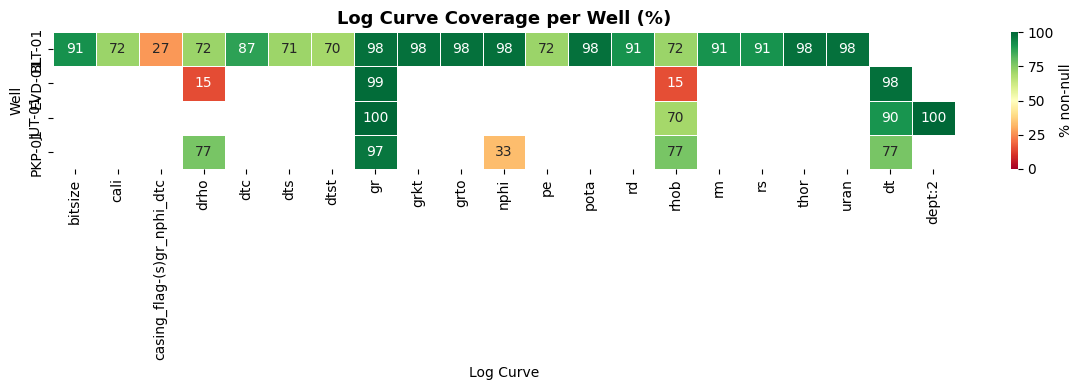

Saved: 01_curve_coverage_heatmap.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    coverage,
    annot=True, fmt=".0f",
    cmap="RdYlGn", vmin=0, vmax=100,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "% non-null"}
)
ax.set_title("Log Curve Coverage per Well (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Log Curve")
ax.set_ylabel("Well")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_curve_coverage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_curve_coverage_heatmap.png")


## 3. Depth range and row counts per well

In [5]:
summary = []
for name, df in wells.items():
    summary.append({
        "Well": name,
        "Rows": len(df),
        "Min Depth (m)": df["DEPTH_M"].min(),
        "Max Depth (m)": df["DEPTH_M"].max(),
        "Step (m)": round(df["DEPTH_M"].diff().median(), 3),
        "Curves present": len([c for c in df.columns if c not in ("WELL_ID","DEPTH_M")])
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


  Well  Rows  Min Depth (m)  Max Depth (m)  Step (m)  Curves present
BLT-01 27875         0.0000      2123.9988     0.076              19
EVD-01 21569        40.1002      2196.9004    -0.100               4
JUT-01 22427         7.0000     11220.0000     0.500               4
PKP-01 27508         0.2002      2750.9004    -0.100               5


## 4. Quick log plots — all 4 wells
GR and RHOB overview across the full depth range.

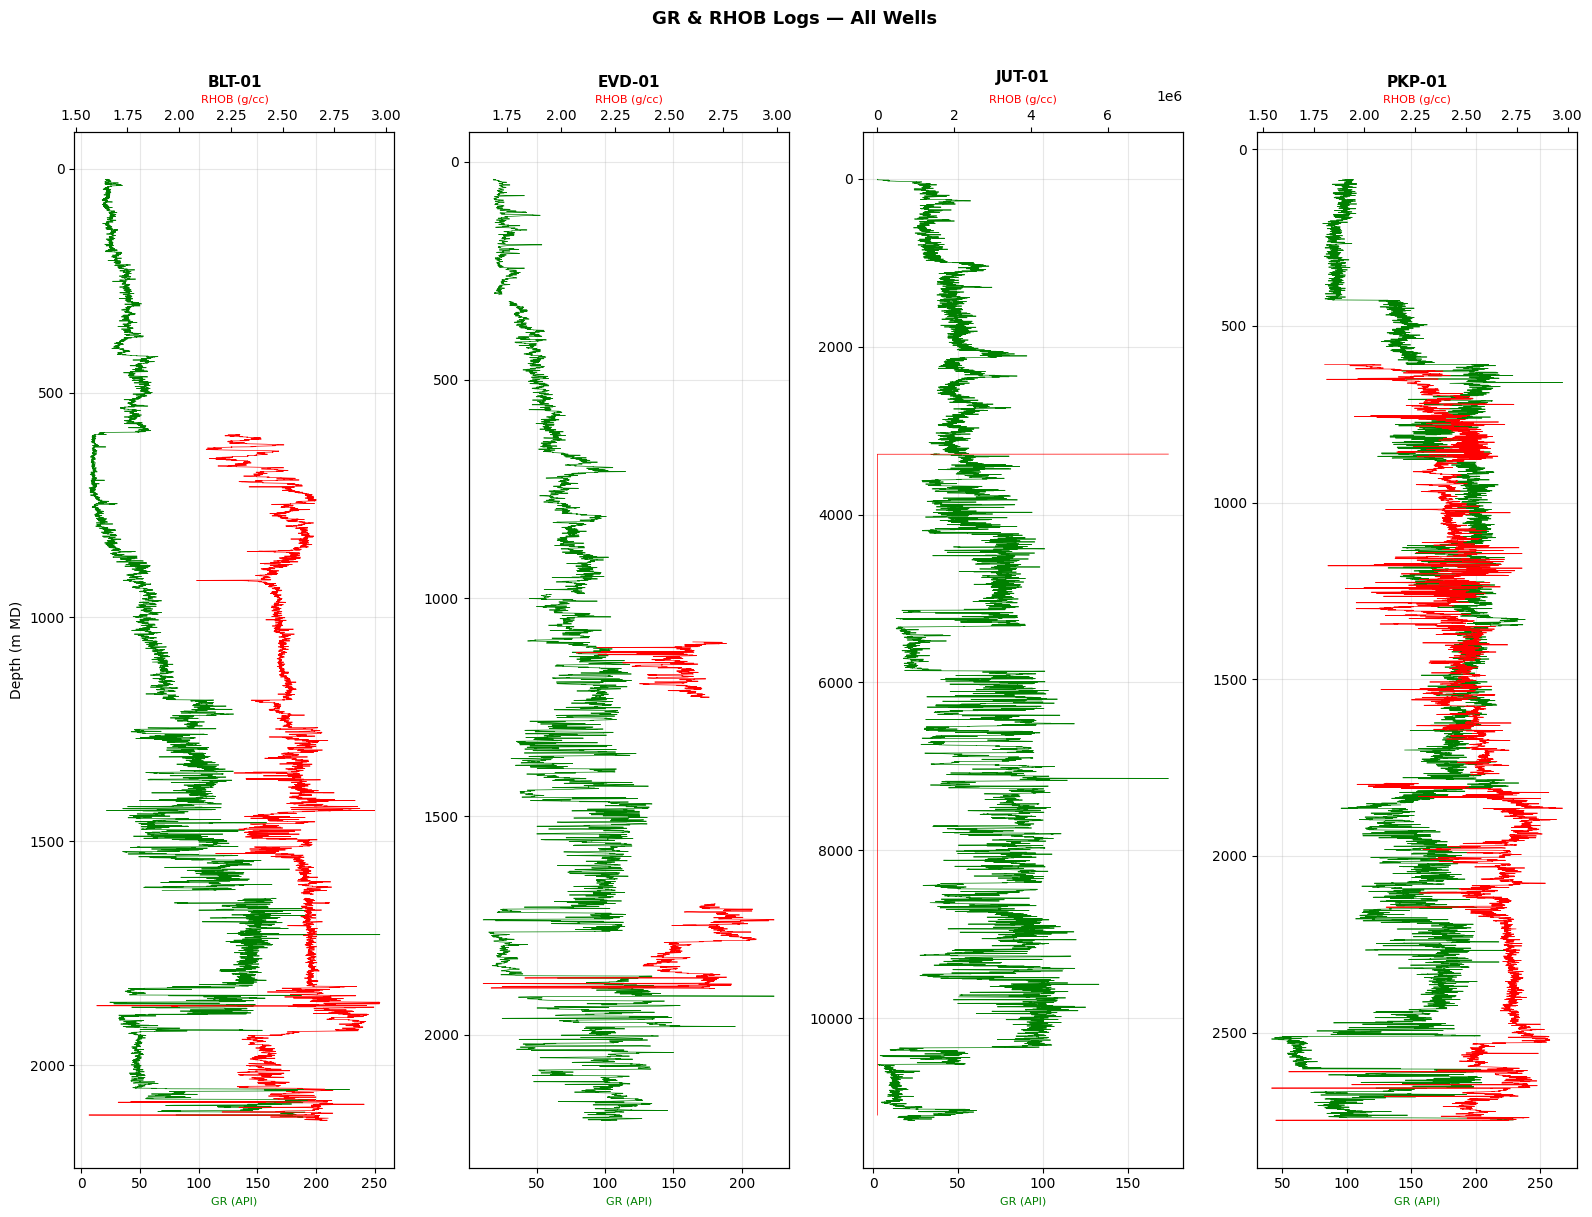

Saved: 01_gr_rhob_overview.png


In [6]:
fig, axes = plt.subplots(1, len(wells), figsize=(4*len(wells), 12), sharey=False)

for ax, (well_name, df) in zip(axes, wells.items()):
    has_gr   = "gr"   in df.columns and df["gr"].notna().any()
    has_rhob = "rhob" in df.columns and df["rhob"].notna().any()

    if has_gr:
        ax.plot(df["gr"],   df["DEPTH_M"], color="green",  lw=0.5, label="GR (API)")
    if has_rhob:
        ax2 = ax.twiny()
        ax2.plot(df["rhob"], df["DEPTH_M"], color="red", lw=0.5, label="RHOB (g/cc)")
        ax2.set_xlabel("RHOB (g/cc)", color="red", fontsize=8)

    ax.invert_yaxis()
    ax.set_ylabel("Depth (m MD)" if well_name == list(wells.keys())[0] else "")
    ax.set_xlabel("GR (API)", color="green", fontsize=8)
    ax.set_title(well_name, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.suptitle("GR & RHOB Logs — All Wells", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_gr_rhob_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_gr_rhob_overview.png")


## 5. Load and inspect external data

In [7]:
# Lithostratigraphic
litho = pd.read_excel(EXTERNAL_DIR / "Lithostratigraphic Data.xlsx", sheet_name=None)
print(f"Lithostratigraphic sheets: {list(litho.keys())}")
for sheet, df in litho.items():
    print(f"  {sheet}: {df.shape} — columns: {list(df.columns)}")
    print(df.head(3).to_string())
    print()


Lithostratigraphic sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
  BLT-01: (44, 5) — columns: ['Stratigrafical unit', 'Unnamed: 1', 'Top (m)', 'Bottom (m)', 'Anomaly code']
     Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
0  Upper North Sea Group         NaN     6.23        7.23          NaN
1       Boxtel Formation         NaN     7.23       14.23          NaN
2      Drenthe Formation         NaN    14.23       24.23          NaN

  EVD-01: (32, 5) — columns: ['Stratigrafical unit', 'Unnamed: 1', 'Top (m)', 'Bottom (m)', 'Anomaly code']
     Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
0  Upper North Sea Group         NaN      0.0       743.0          NaN
1  Veldhoven Clay Member         NaN    743.0       807.0          NaN
2      Rupel Clay Member         NaN    807.0       921.0          NaN

  JUT-01: (47, 5) — columns: ['Stratigrafical unit', 'Unnamed: 1', 'Top (m)', 'Bottom (m)', 'Anomaly code']
    Stratigrafical unit  Unnamed: 1  T

In [8]:
# ThermoGIS
thermo = pd.read_excel(EXTERNAL_DIR / "ThermoGIS Data.xlsx", sheet_name=None)
print(f"ThermoGIS sheets: {list(thermo.keys())}")
for sheet, df in thermo.items():
    print(f"  {sheet}: {df.shape}")
    print(df.head(5).to_string())
    print()


ThermoGIS sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
  BLT-01: (14, 5)
      Well Name     PKP-01 Unnamed: 2 Unnamed: 3 Unnamed: 4
0             x  141577.55        NaN        NaN        NaN
1             Y  456881.76        NaN        NaN        NaN
2           NaN        NaN        NaN        NaN        NaN
3      Property       Unit        P90        P50        P10
4  Permeability         mD         13         82        521

  EVD-01: (14, 5)
      Well Name  EVD-01 Unnamed: 2 Unnamed: 3 Unnamed: 4
0             x  136997        NaN        NaN        NaN
1             Y  441189        NaN        NaN        NaN
2           NaN     NaN        NaN        NaN        NaN
3      Property    Unit        P90        P50        P10
4  Permeability      mD          3          6         11

  JUT-01: (14, 5)
      Well Name  JUT-01 Unnamed: 2 Unnamed: 3 Unnamed: 4
0             x  134098        NaN        NaN        NaN
1             Y  451726        NaN        NaN        NaN
2           

In [9]:
# Well path data (needed for JUT-01 TVD conversion)
well_path = pd.read_excel(EXTERNAL_DIR / "Well Path Data.xlsx", sheet_name=None)
print(f"Well Path sheets: {list(well_path.keys())}")
for sheet, df in well_path.items():
    print(f"  {sheet}: {df.shape} — columns: {list(df.columns)}")
    print(df.head(3).to_string())
    print()


Well Path sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
  BLT-01: (102, 6) — columns: ['Depth (m)', 'Inclination (º)', 'Azimuth (º)', 'TVD (m)', 'X-offset (m)', 'Y-offset (m)']
   Depth (m)  Inclination (º)  Azimuth (º)  TVD (m)  X-offset (m)  Y-offset (m)
0       0.00             0.00          0.0     0.00           0.0          0.00
1       6.23             0.00          0.0     6.23           0.0          0.00
2      53.00             0.26          0.0    53.00           0.0          0.11

  EVD-01: (21, 6) — columns: ['Depth (m)', 'Inclination (º)', 'Azimuth (º)', 'TVD (m)', 'X-offset (m)', 'Y-offset (m)']
   Depth (m)  Inclination (º)  Azimuth (º)  TVD (m)  X-offset (m)  Y-offset (m)
0      300.0             0.22          147    300.0          0.33         -0.47
1      400.0             0.30          147    400.0          0.59         -0.84
2      500.0             0.10          250    500.0          0.66         -1.09

  JUT-01: (33, 6) — columns: ['Depth (m)', 'Inclination (º

In [10]:
# target_lithologies.csv
target_litho = pd.read_csv(EXTERNAL_DIR / "target_lithologies.csv")
print(f"target_lithologies.csv: {target_litho.shape}")
print(target_litho.dtypes)
print()
print(target_litho.head(10).to_string())


target_lithologies.csv: (3455, 13)
well_id                      str
easting                  float64
northing                 float64
depth_tvd_m              float64
porosity_pct             float64
gamma_ray_api            float64
bulk_density_gcc         float64
formation_top_tvd        float64
formation_base_tvd       float64
formation_thickness_m    float64
distance_to_usp_km       float64
flag                         str
flag_reason                  str
dtype: object

  well_id   easting  northing  depth_tvd_m  porosity_pct  gamma_ray_api  bulk_density_gcc  formation_top_tvd  formation_base_tvd  formation_thickness_m  distance_to_usp_km   flag                                               flag_reason
0  JUT-01  134098.0  451726.0          NaN           NaN        43.6703               NaN             1659.5              1787.0                  127.5            7.748434  check  AH depth — deviated well needs TVD conversion before use
1  JUT-01  134098.0  451726.0          NaN     

In [11]:
# Flag summary from target_lithologies
if "flag" in target_litho.columns or "flag_reason" in target_litho.columns:
    flag_col = "flag" if "flag" in target_litho.columns else "flag_reason"
    print("Flag distribution:")
    print(target_litho[flag_col].value_counts())


Flag distribution:


flag
check    3455
Name: count, dtype: int64


## 6. Key observations
Update this cell after running the notebook.

In [12]:
print("""
KEY OBSERVATIONS FROM DATA EXPLORATION
======================================
- BLT-01: Most complete log suite — best candidate for training ML models
- EVD-01: Sparse curves — will need imputation for NPHI, DTS, resistivity
- JUT-01: Deviated well — MUST convert MD to TVD before any depth analysis
- PKP-01: Moderate coverage — needs NPHI and DTS imputation

Next step: Notebook 02 — Data Cleaning & Schema Building
""")



KEY OBSERVATIONS FROM DATA EXPLORATION
- BLT-01: Most complete log suite — best candidate for training ML models
- EVD-01: Sparse curves — will need imputation for NPHI, DTS, resistivity
- JUT-01: Deviated well — MUST convert MD to TVD before any depth analysis
- PKP-01: Moderate coverage — needs NPHI and DTS imputation

Next step: Notebook 02 — Data Cleaning & Schema Building

